# TalentSync AI - Data Preprocessing & Synthesis

This notebook generates a synthetic dataset of resumes and job descriptions to train and evaluate the resume matching platform. It satisfies the following requirements:
- Generates at least **200 distinct resumes**.
- Generates at least **50 job descriptions**.
- Converts resumes to structured, text-based PDF files using `reportlab`.
- Constructs train/test splits for the embedding models.
- Evaluates and visualizes the dataset statistics.

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
import pdfplumber

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)

# Ensure directories exist
os.makedirs('../data/resumes', exist_ok=True)
print("Directories verified!")

Directories verified!


## 1. Templates & Dictionaries

We define candidate skills, companies, educational institutions, degrees, roles, and project templates. We explicitly inject the required skill synonyms:
- `JavaScript` vs `JS`
- `Machine Learning` vs `ML`
- `PostgreSQL` vs `Postgres`
- `C#` vs `C Sharp` vs `.NET`

In [2]:
ROLES = [
    "Software Engineer", "Frontend Developer", "Backend Developer", 
    "Data Scientist", "Machine Learning Engineer", "DevOps Engineer", 
    "Product Manager", "QA Engineer"
]

COMPANIES = [
    "Google", "Microsoft", "Meta", "Amazon", "Netflix", "Apple", 
    "Stripe", "Uber", "Airbnb", "Salesforce", "Atlassian", "Slack", 
    "ABC Technologies", "XYZ Solutions", "Innovate Labs", "Global Tech"
]

UNIVERSITIES = [
    "Stanford University", "MIT", "UC Berkeley", "Carnegie Mellon University", 
    "Georgia Tech", "Caltech", "University of Washington", "University of Michigan",
    "State University", "City College", "Ivy League University", "Tech Institute"
]

DEGREES = [
    ("Bachelor of Science", "Computer Science", 1.0),
    ("Master of Science", "Computer Science", 1.0),
    ("Bachelor of Science", "Information Technology", 0.9),
    ("Master of Science", "Data Science", 0.95),
    ("Doctor of Philosophy", "Computer Science", 1.0),
    ("Bachelor of Engineering", "Electrical Engineering", 0.8),
    ("Master of Business Administration", "Product Management", 0.7),
    ("Bachelor of Arts", "History", 0.2), # Unrelated for checking education match
]

SKILLS_POOL = {
    "Software Engineer": [
        ["JavaScript", "JS"], ["Python", "Python3"], ["C#", "C Sharp", ".NET"], 
        ["Java"], ["PostgreSQL", "Postgres"], ["SQL", "MySQL"], ["Docker"], 
        ["AWS"], ["Git"], ["REST APIs"], ["Data Structures"], ["Algorithms"]
    ],
    "Frontend Developer": [
        ["JavaScript", "JS"], ["React"], ["HTML5"], ["CSS3"], ["Sass"], 
        ["Vue"], ["TypeScript", "TS"], ["Webpack"], ["Bootstrap"], ["Tailwind"]
    ],
    "Backend Developer": [
        ["Python"], ["Node.js", "Node"], ["Java"], ["Go", "Golang"], 
        ["PostgreSQL", "Postgres"], ["MongoDB"], ["Redis"], ["Docker"], 
        ["Kubernetes"], ["AWS"], ["REST APIs"], ["GraphQL"], ["C#", "C Sharp", ".NET"]
    ],
    "Data Scientist": [
        ["Python"], ["R"], ["SQL"], ["Machine Learning", "ML"], 
        ["Deep Learning"], ["Pandas"], ["NumPy"], ["Scikit-Learn", "Sklearn"], 
        ["PostgreSQL", "Postgres"], ["Tableau"], ["Data Analysis"], ["Statistics"]
    ],
    "Machine Learning Engineer": [
        ["Python"], ["Machine Learning", "ML"], ["Deep Learning"], 
        ["PyTorch"], ["TensorFlow"], ["NLP"], ["Computer Vision"], 
        ["Scikit-Learn", "Sklearn"], ["Docker"], ["MLflow"], ["AWS"]
    ],
    "DevOps Engineer": [
        ["Docker"], ["Kubernetes"], ["AWS"], ["Terraform"], ["Ansible"], 
        ["Linux"], ["Bash"], ["CI/CD"], ["Jenkins"], ["Python"], ["Prometheus"]
    ],
    "Product Manager": [
        ["Product Roadmap"], ["Agile"], ["Scrum"], ["Jira"], ["SQL"], 
        ["A/B Testing"], ["Market Analysis"], ["User Stories"], ["Strategy"]
    ],
    "QA Engineer": [
        ["Selenium"], ["Playwright"], ["Python"], ["JavaScript", "JS"], 
        ["SQL"], ["Manual Testing"], ["API Testing"], ["Postman"], ["CI/CD"]
    ]
}

PROJECT_TEMPLATES = {
    "Software Engineer": [
        "Developed a distributed key-value store using C# and .NET with high throughput.",
        "Built a responsive web platform utilizing JavaScript (JS) and React on the frontend.",
        "Designed and query-optimized an enterprise-scale relational database using PostgreSQL (Postgres).",
        "Containerized multi-service web applications using Docker and deployed on AWS."
    ],
    "Frontend Developer": [
        "Designed a modular e-commerce dashboard using React, Tailwind CSS, and TypeScript.",
        "Re-architected client-facing web application with modern JavaScript (JS) reducing page loads.",
        "Built a collaborative drag-and-drop workspace using HTML5, CSS3, and Sass.",
        "Developed a responsive components library styled with Bootstrap and integrated with Vue."
    ],
    "Backend Developer": [
        "Developed high-performance microservices in Go and Python communicating via REST and gRPC.",
        "Designed database schema for an ERP system on PostgreSQL (Postgres), reducing query times.",
        "Built a real-time messaging gateway utilizing Node.js, WebSockets, and Redis cache.",
        "Implemented enterprise authentication APIs using ASP.NET Core in C Sharp (.NET)."
    ],
    "Data Scientist": [
        "Built a customer churn predictive model using Machine Learning (ML) and XGBoost on tabular data.",
        "Performed statistical analysis on huge marketing datasets with Pandas, NumPy, and Tableau.",
        "Developed a recommendation system based on natural language reviews and Pandas.",
        "Analyzed user search behavior datasets stored in PostgreSQL (Postgres) to extract key patterns."
    ],
    "Machine Learning Engineer": [
        "Trained and fine-tuned a BERT-based NLP model using PyTorch for sentiment classification.",
        "Deployed a computer vision pipeline with TensorFlow and OpenCV for object detection.",
        "Built an automated end-to-end Machine Learning (ML) retraining pipeline using MLflow.",
        "Designed large-scale similarity search index using Sentence Transformers on AWS."
    ],
    "DevOps Engineer": [
        "Designed infrastructure-as-code deployments using Terraform to manage AWS resources.",
        "Orchestrated auto-scaling Kubernetes clusters with Prometheus monitoring dashboard.",
        "Established secure CI/CD build pipelines using GitHub Actions and Docker.",
        "Automated system configuration and package management using Ansible playbooks."
    ],
    "Product Manager": [
        "Launched a mobile app product roadmap driving user growth and engagement metrics.",
        "Managed agile sprint backlogs and product requirements in Jira across 3 cross-functional teams.",
        "Designed and executed user retention A/B testing campaigns, parsing telemetry with SQL.",
        "Conducted target market analysis and defined functional user stories for beta launch."
    ],
    "QA Engineer": [
        "Automated web application testing using Selenium WebDriver and Python pytest.",
        "Constructed end-to-end regression testing suites using Playwright and JavaScript (JS).",
        "Executed manual and automated API validation tests with Postman and custom scripts.",
        "Integrated test automation scripts into GitLab CI/CD pipeline for pull request validations."
    ]
}

## 2. Generating Resumes

We will generate at least **200 resumes** as text-based PDFs. We will write the files to `../data/resumes/resume_xxx.pdf`. We will ensure that section headers are explicitly and correctly placed to follow the parsing rules. We will also include a few invalid/scanned resumes to test boundaries.

In [3]:
def pick_random_skills(role, count=5):
    selected = []
    role_pool = SKILLS_POOL[role]
    chosen_lists = random.sample(role_pool, min(count, len(role_pool)))
    for cl in chosen_lists:
        # randomly select one synonym form
        selected.append(random.choice(cl))
    return selected

def generate_resume_text(index, role):
    # Select header names randomly from the valid headers to ensure robustness
    skills_headers = ["Skills", "Technical Skills", "Core Skills"]
    exp_headers = ["Experience", "Work Experience", "Professional Experience", "Internships"]
    proj_headers = ["Projects", "Academic Projects", "Personal Projects"]
    edu_headers = ["Education", "Academic Background"]

    # Generate Sections
    skills = pick_random_skills(role, count=random.randint(6, 9))
    
    # Experience Validation Rule test:
    # 95% of resumes will have valid experience (Role, Company, Duration)
    # 5% will have invalid/missing data to verify parser
    has_valid_exp = random.random() < 0.95
    exp_entries = []
    if has_valid_exp:
        for _ in range(random.randint(1, 2)):
            comp = random.choice(COMPANIES)
            dur = f"{random.choice(['January', 'June', 'September'])} {random.randint(2020, 2023)} - {random.choice(['August', 'December'])} {random.randint(2024, 2025)}"
            exp_role = f"{random.choice(['Senior', 'Junior', 'Associate', 'Lead', ''])} {role}".strip()
            exp_entries.append(f"{exp_role}\n{comp}\n{dur}\n- Designed and implemented major components.\n- Collaborated with cross-functional teams to deliver scale products.")
    else:
        # Invalid experience
        exp_entries.append("Worked as a general programmer on multiple client sites doing general tasks without specified duration.")

    # Projects
    proj_entries = []
    proj_templates = PROJECT_TEMPLATES[role]
    chosen_projs = random.sample(proj_templates, min(2, len(proj_templates)))
    for p in chosen_projs:
        proj_title = f"{role.replace(' ', '')} {random.randint(100, 999)}"
        proj_entries.append(f"{proj_title}\n{p}")
        
    # Education
    edu_choice = random.choice(DEGREES)
    degree, field, _ = edu_choice
    uni = random.choice(UNIVERSITIES)
    edu_year = random.randint(2015, 2024)
    edu_text = f"{degree} in {field}\n{uni}, {edu_year}"

    resume_dict = {
        "name": f"Candidate_{index}",
        "target_role": role,
        "skills_header": random.choice(skills_headers),
        "skills": ", ".join(skills),
        "exp_header": random.choice(exp_headers),
        "experience": "\n\n".join(exp_entries),
        "proj_header": random.choice(proj_headers),
        "projects": "\n\n".join(proj_entries),
        "edu_header": random.choice(edu_headers),
        "education": edu_text
    }
    return resume_dict

resumes_data = []
for i in range(1, 201):
    role = random.choice(ROLES)
    resumes_data.append(generate_resume_text(i, role))

# Add 5 image-only/scanned style empty resumes to verify rejection later
for i in range(201, 206):
    resumes_data.append({
        "name": f"Scanned_Candidate_{i}",
        "target_role": "Software Engineer",
        "skills_header": "Skills",
        "skills": "", # empty content simulates scanned/empty text extraction
        "exp_header": "Experience",
        "experience": "",
        "proj_header": "Projects",
        "projects": "",
        "edu_header": "Education",
        "education": ""
    })

print(f"Generated data profiles for {len(resumes_data)} candidates.")

Generated data profiles for 205 candidates.


### 2.1 Generating PDFs using ReportLab
We now compile the candidate profiles into physical PDF documents in `../data/resumes/`.

In [4]:
styles = getSampleStyleSheet()
normal_style = styles['Normal']
title_style = ParagraphStyle(
    'TitleStyle',
    parent=styles['Heading1'],
    fontSize=18,
    spaceAfter=12
)
h2_style = ParagraphStyle(
    'H2Style',
    parent=styles['Heading2'],
    fontSize=14,
    spaceBefore=10,
    spaceAfter=6
)

def build_pdf(resume, file_path):
    doc = SimpleDocTemplate(file_path, pagesize=letter, rightMargin=40, leftMargin=40, topMargin=40, bottomMargin=40)
    story = []
    
    # Name & Contact Info
    story.append(Paragraph(resume["name"], title_style))
    story.append(Paragraph(f"Email: {resume['name'].lower()}@example.com | Target Role: {resume['target_role']}", normal_style))
    story.append(Spacer(1, 15))
    
    # If it is a mock scanned resume, do not write sections to keep extracted text empty
    if "Scanned" in resume["name"]:
        # Write empty or trivial drawing canvas, no text blocks
        story.append(Spacer(1, 10))
        doc.build(story)
        return

    # Skills Section
    story.append(Paragraph(resume["skills_header"], h2_style))
    story.append(Paragraph(resume["skills"], normal_style))
    story.append(Spacer(1, 10))
    
    # Experience Section
    story.append(Paragraph(resume["exp_header"], h2_style))
    for line in resume["experience"].split("\n"):
        story.append(Paragraph(line, normal_style))
    story.append(Spacer(1, 10))

    # Projects Section
    story.append(Paragraph(resume["proj_header"], h2_style))
    for line in resume["projects"].split("\n"):
        story.append(Paragraph(line, normal_style))
    story.append(Spacer(1, 10))
    
    # Education Section
    story.append(Paragraph(resume["edu_header"], h2_style))
    for line in resume["education"].split("\n"):
        story.append(Paragraph(line, normal_style))
        
    doc.build(story)

for idx, res in enumerate(resumes_data):
    path = f"../data/resumes/resume_{idx+1:03d}.pdf"
    build_pdf(res, path)

print("All 205 PDFs constructed successfully in ../data/resumes/")

All 205 PDFs constructed successfully in ../data/resumes/


## 3. Generating Job Descriptions

We need to generate at least **50 job descriptions**. We will save these to a JSON database file `../data/jobs.json`.

In [5]:
jobs_data = []
for i in range(1, 51):
    role = random.choice(ROLES)
    # select required skills from pool
    required_skills = [random.choice(sk) for sk in random.sample(SKILLS_POOL[role], min(5, len(SKILLS_POOL[role])))]
    
    # create experience requirements
    min_years = random.choice([2, 3, 5])
    exp_req = f"{min_years}+ years of experience working as a {role} or similar position."
    
    # project requirements
    proj_templates = PROJECT_TEMPLATES[role]
    proj_req = f"Looking for candidates who have experience in projects such as: {random.choice(proj_templates)}"
    
    # education requirements
    edu_choice = random.choice(DEGREES[:6]) # exclude unrelated degree for jobs
    degree, field, _ = edu_choice
    edu_req = f"{degree} in {field} or equivalent technical experience."
    
    job = {
        "id": f"JOB_{i:02d}",
        "title": f"{role} - Category {random.choice(['A', 'B', 'C'])}",
        "role": role,
        "required_skills": required_skills,
        "experience_requirements": {
            "years": min_years,
            "role_match": role,
            "description": exp_req
        },
        "project_requirements": {
            "description": proj_req
        },
        "education_requirements": {
            "degree": degree,
            "field": field,
            "description": edu_req
        }
    }
    jobs_data.append(job)

with open('../data/jobs.json', 'w') as f:
    json.dump(jobs_data, f, indent=2)

print(f"Saved {len(jobs_data)} job descriptions to ../data/jobs.json")

Saved 50 job descriptions to ../data/jobs.json


## 4. Fine-Tuning Training Dataset Generation

We need to train our Sentence Transformers model to recognize the semantic relationships between resumes and jobs. We will construct a synthetic dataset of triplets (Anchor, Positive, Negative) or query-document scores to perform fine-tuning. Let's create a dataset mapping matching resumes (positive) vs non-matching resumes (negative) for each job.

In [6]:
training_pairs = []
evaluation_pairs = []

# Create training pairs
# We will use the first 40 jobs and 150 resumes for training,
# and the remaining 10 jobs and 50 resumes for evaluation.
train_jobs = jobs_data[:40]
eval_jobs = jobs_data[40:]

train_resumes = resumes_data[:150]
eval_resumes = resumes_data[150:200] # exclude mock scanned resumes

def create_pairs(jobs_subset, resumes_subset, file_prefix):
    pairs = []
    for job in jobs_subset:
        job_text = f"Job Title: {job['title']}\nRole: {job['role']}\nSkills: {', '.join(job['required_skills'])}\nProjects: {job['project_requirements']['description']}\nEducation: {job['education_requirements']['description']}"
        for resume in resumes_subset:
            resume_text = f"Resume of {resume['name']}\nSkills: {resume['skills']}\nExperience: {resume['experience']}\nProjects: {resume['projects']}\nEducation: {resume['education']}"
            
            # Determine relevance
            # Score 1.0 if role matches, 0.0 otherwise
            label = 1.0 if resume['target_role'] == job['role'] else 0.0
            pairs.append({
                "job": job_text,
                "resume": resume_text,
                "label": label
            })
    return pairs

train_pairs_list = create_pairs(train_jobs, train_resumes, 'train')
eval_pairs_list = create_pairs(eval_jobs, eval_resumes, 'eval')

with open('../data/train_dataset.json', 'w') as f:
    json.dump(train_pairs_list, f, indent=2)

with open('../data/eval_dataset.json', 'w') as f:
    json.dump(eval_pairs_list, f, indent=2)

print(f"Created {len(train_pairs_list)} training pairs and {len(eval_pairs_list)} evaluation pairs.")

Created 6000 training pairs and 500 evaluation pairs.


## 5. Dataset Visualizations

Let's visualize the synthetic data distribution to verify balancing.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_32324\1338580178.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=job_roles, order=ROLES, palette='viridis')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_32324\1338580178.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=resume_roles, order=ROLES, palette='magma')


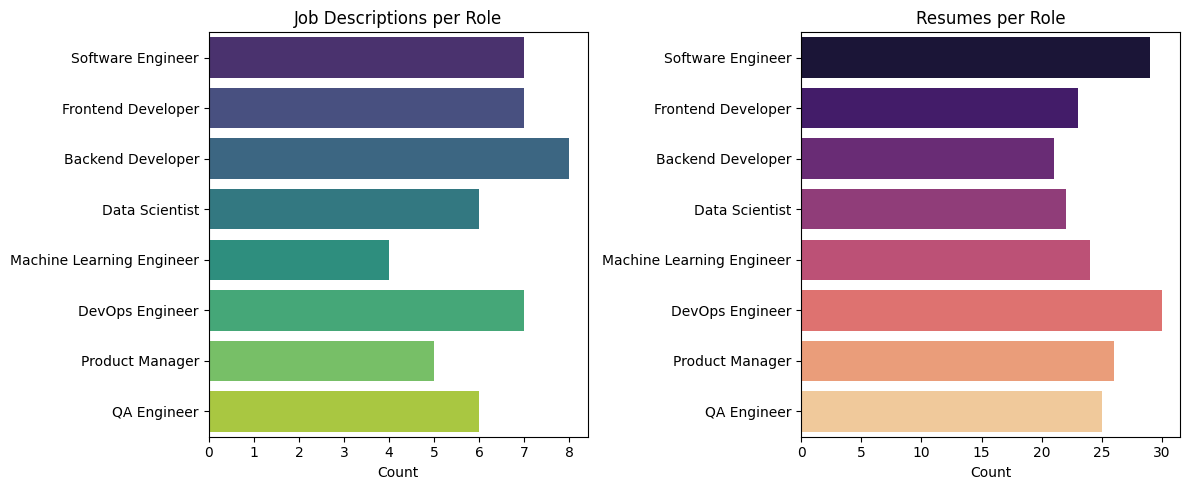

In [7]:
# Plot distribution of jobs and resumes by role
job_roles = [j['role'] for j in jobs_data]
resume_roles = [r['target_role'] for r in resumes_data if 'Scanned' not in r['name']]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(y=job_roles, order=ROLES, palette='viridis')
plt.title('Job Descriptions per Role')
plt.xlabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(y=resume_roles, order=ROLES, palette='magma')
plt.title('Resumes per Role')
plt.xlabel('Count')

plt.tight_layout()
plt.savefig('../app/static/charts/dataset_distribution.png')
plt.show()